# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Inicializacion y vista previa

In [1]:
# importar librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
from statsmodels.tsa.seasonal import seasonal_decompose
 
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, make_scorer 

from sklearn.linear_model import LinearRegression   
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [2]:
# cargar datos y establecer la columna 0 como datos de tipo datetime
#df = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])
df = pd.read_csv('taxi.csv', index_col=[0], parse_dates=[0])

In [3]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


In [4]:
#vista previa
df.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [5]:
#rango de fechas de los datos
print('Rango de fechas disponible: ',df.index.min(),' - ', df.index.max())

Rango de fechas disponible:  2018-03-01 00:00:00  -  2018-08-31 23:50:00


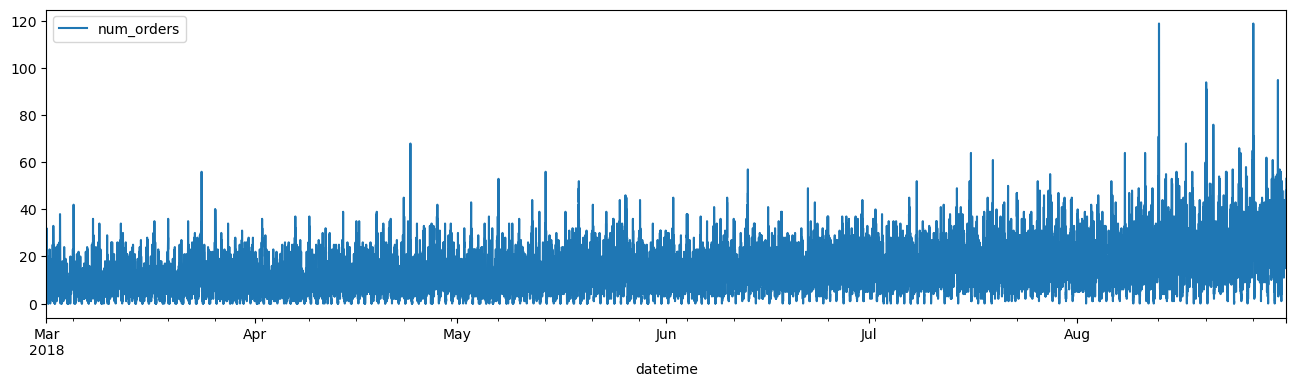

In [6]:
#grafica de los datos cada 10 minutos
df.plot(figsize=(16,4))
plt.show()

**Descripción de los datos**
- `datetime` - fecha y hora del muestreo
- `num_orders` - número de pedidos de taxis

Se tienen datos del 1 de marzo del 2018 al 31 de agosto del 2018.

No hay presencia de valores ausentes.

Los datos estan muestreados cada 10 minutos, pero el análisis requiere los datos por hora. 

## Análisis
Se hace el remuestreo por hora.

In [7]:
# comprobar que las fechas estan en orden
df.index.is_monotonic_increasing

True

In [8]:
#remuestreo por hora
df = df.resample('1h').sum()
df.head(3)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71


In [9]:
# crear columna con media movil con tamaño de ventana de 6 horas
# se usa shift porque el valor actual de una fila no se puede utilizar para calcular la media móvil
df['rolling_mean_6'] = df['num_orders'].shift().rolling(6).mean()

#vista previa
df.sample(3)

,num_orders,rolling_mean_6
datetime,,
2018-06-16 20:00:00,50,92.333333
2018-04-27 02:00:00,73,91.500000
2018-05-09 10:00:00,43,35.166667


**Influencia del la hora en el número de pedidos**

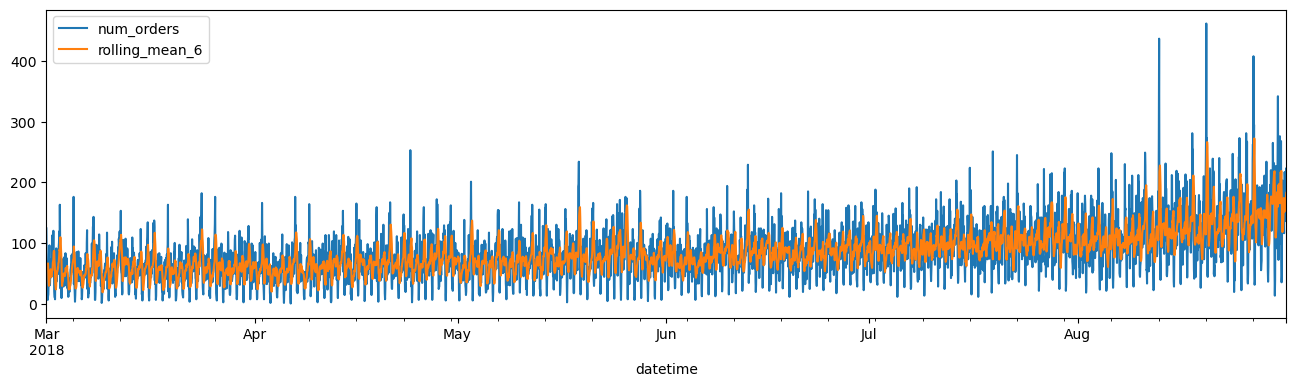

In [10]:
#grafica con remuestreo de 1 hora
df.plot(figsize=(16,4))
plt.show()

Descomponer los datos en tendencia, componente estacional y residuos

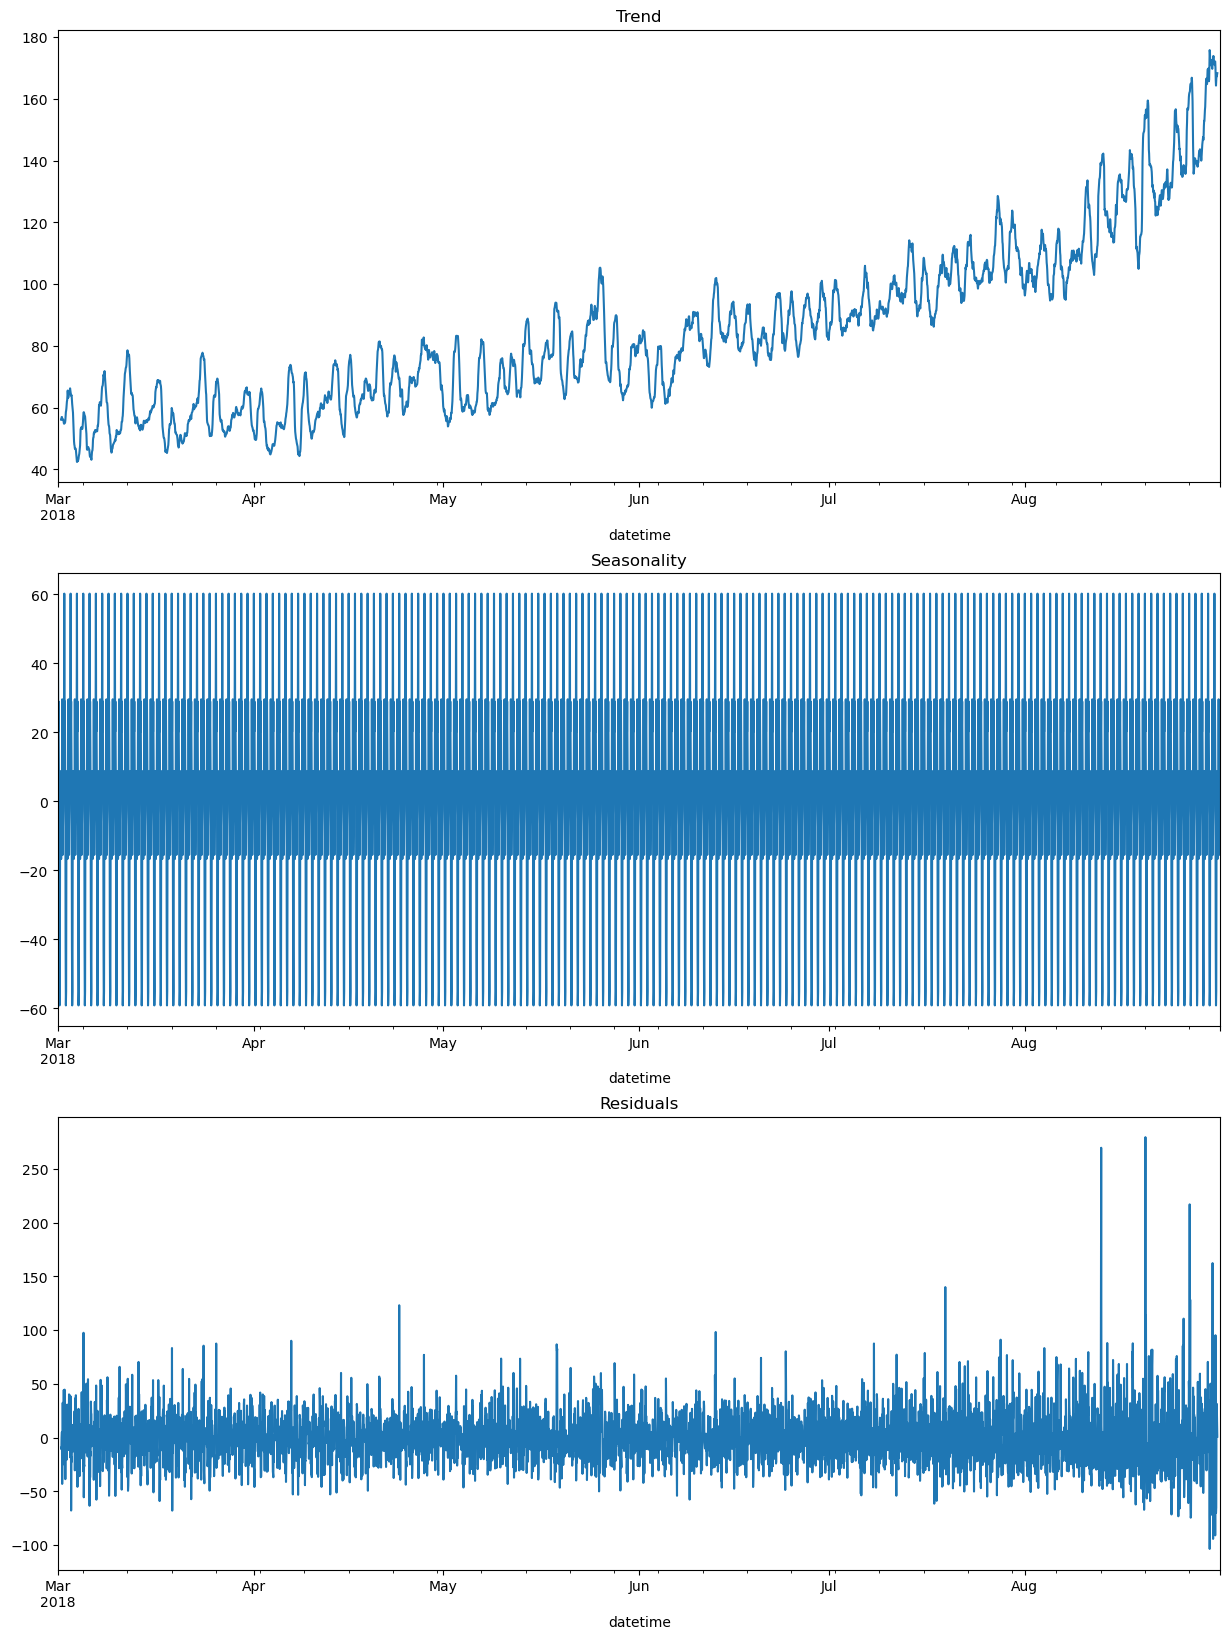

In [11]:
decomposed = seasonal_decompose(df['num_orders'])

plt.figure(figsize=(15, 20))  

plt.subplot(311) #3 filas, 1 columna - primera imagen
decomposed.trend.plot(ax=plt.gca())  # plt.gca() --> Get the current Axes 
plt.title('Trend')  

plt.subplot(312)  
decomposed.seasonal.plot(ax=plt.gca()) 
plt.title('Seasonality')  

plt.subplot(313)  
decomposed.resid.plot(ax=plt.gca())  
plt.title('Residuals') 

plt.show()

La primera gráfica muestra una tendencia positiva, ya que con el paso de los meses, la cantidad de taxis solicitados incrementa.

El componente estacional oscila alrededor de cero, no se aprecia un patrón claramente repetitivo, por lo que sería necesario contar con un periodo más largo para identificar una estacionalidad bien definida.

La gráfica de los residuos o ruido muestra algunos valores atípicos, con un aumento notable en la variabilidad durante el mes de agosto.

In [12]:
# Exploración por hora
df.groupby(df.index.hour)['num_orders'].describe()

,count,mean,std,min,25%,50%,75%,max
datetime,,,,,,,,
0,184.0,144.402174,49.224380,42.0,104.00,142.0,167.50,281.0
1,184.0,104.364130,47.611853,33.0,73.00,93.5,124.25,273.0
2,184.0,113.070652,65.815443,20.0,68.75,104.5,146.00,462.0
3,184.0,102.021739,44.282125,24.0,68.00,96.5,128.00,267.0
4,184.0,86.907609,52.755930,15.0,43.00,83.0,117.00,295.0
5,184.0,42.630435,26.754997,1.0,20.75,37.5,61.25,121.0
6,184.0,25.173913,21.288345,0.0,9.00,19.0,35.00,95.0
7,184.0,29.271739,15.869759,5.0,18.00,27.0,38.00,103.0
8,184.0,73.048913,24.663258,25.0,58.00,71.5,85.00,182.0


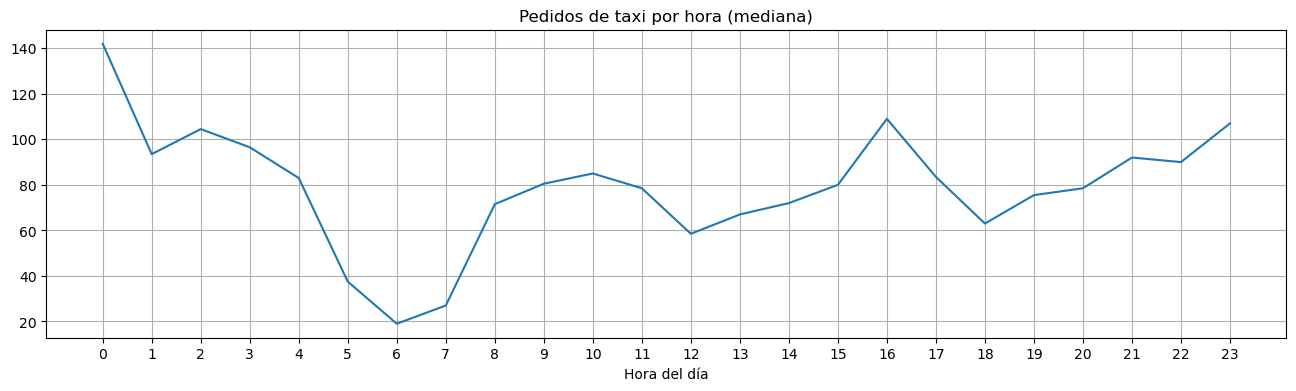

In [13]:
# Gráfica por hora
df.groupby(df.index.hour)['num_orders'].median().plot(figsize=(16,4))
plt.xticks(ticks=range(24), labels=range(24))
plt.xlabel("Hora del día")
plt.title("Pedidos de taxi por hora (mediana)")
plt.grid(True)
plt.show()

Alrededor de las 6 y 7 de la mañana, se requiere el menor número de taxis. 

Alrededor de las 11pm hasta las 3am es donde más taxis se requieren. Este comportamiento es similar a las 4pm.

**Influencia del mes en el número de pedidos**

In [14]:
# Exploración de valores mensuales (ME: month end)
#df.resample('M')['num_orders'].describe()  # DEPRECATED
df['num_orders'].resample('ME').agg(['count', 'mean', 'std', 'min', 'max', 'sum'])


,count,mean,std,min,max,sum
datetime,,,,,,
2018-03-31,744,57.483871,29.562439,1,182,42768
2018-04-30,720,63.804167,32.036301,0,253,45939
2018-05-31,744,73.682796,34.849825,2,234,54820
2018-06-30,720,83.202778,32.826776,6,229,59906
2018-07-31,744,100.006720,37.254770,11,251,74405
2018-08-31,744,127.651882,56.242228,13,462,94973


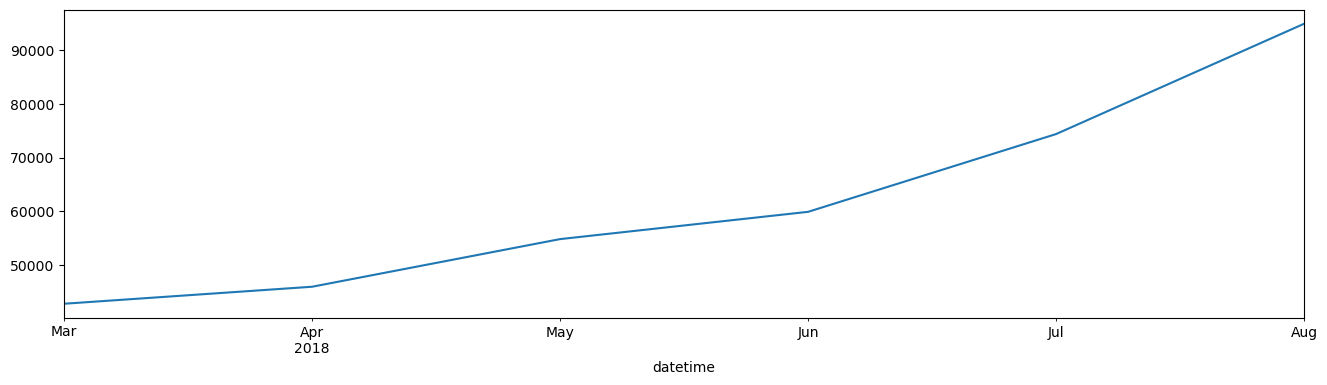

In [15]:
# Exploración por mes
df['num_orders'].resample('ME').sum().plot(figsize=(16,4))
plt.show()

A lo largo del año, el número de pedidos de taxis muestra una tendencia creciente. 

En agosto, el último mes registrado, la cantidad de pedidos se duplica en comparación con marzo, el mes inicial.

## Formación

Se crean características para el pronóstico y se entrenan diferentes modelos con diferentes hiperparámetros.

**Crear características para el pronóstico**

Se crean las siguientes características para los modelos predictivos, a excepción del modelo constante.
- características del calendario: mes, día del mes y día de la semana
- características de desfase: usa valores anteriores para saber si los pedidos aumentaran o disminuiran
- característica de media móvil: establece la tendencia general de la serie temporal

In [16]:
# Crear características del calendario   
df['month'] = df.index.month
#df['week'] = df.index.isocalendar().week
df['day'] =   df.index.day
df['dayofweek'] = df.index.dayofweek
df['hour'] =  df.index.hour

In [17]:
#desfase máximo
max_lag = 5

# Crear características de desfase
for lag in range(1, max_lag + 1):
    df['lag_{}'.format(lag)] = df['num_orders'].shift(lag) 

In [18]:
#vista previa
df.head(10)

,num_orders,rolling_mean_6,month,day,dayofweek,hour,lag_1,lag_2,lag_3,lag_4,lag_5
datetime,,,,,,,,,,,
2018-03-01 00:00:00,124,NaN,3,1,3,0,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,NaN,3,1,3,1,124.0,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,NaN,3,1,3,2,85.0,124.0,NaN,NaN,NaN
2018-03-01 03:00:00,66,NaN,3,1,3,3,71.0,85.0,124.0,NaN,NaN
2018-03-01 04:00:00,43,NaN,3,1,3,4,66.0,71.0,85.0,124.0,NaN
2018-03-01 05:00:00,6,NaN,3,1,3,5,43.0,66.0,71.0,85.0,124.0
2018-03-01 06:00:00,12,65.833333,3,1,3,6,6.0,43.0,66.0,71.0,85.0
2018-03-01 07:00:00,15,47.166667,3,1,3,7,12.0,6.0,43.0,66.0,71.0
2018-03-01 08:00:00,34,35.500000,3,1,3,8,15.0,12.0,6.0,43.0,66.0


**Separar datos en conjunto de prueba y entrenamiento**

La muestra de prueba se hace con el 10% del conjunto de datos inicial.

In [19]:
# eliminar valores ausentes
df = df.dropna() 

In [20]:
#separar características de objetivo
features = df.drop(['num_orders'],axis=1)
target = df['num_orders']

#separar conjunto de entrenamiento y prueba
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.1, shuffle=False)

In [21]:
print('train shape: ', features_train.shape)
print('test shape: ', features_test.shape)

train shape:  (3969, 10)
test shape:  (441, 10)


In [22]:
#comprobar que el conjunto de datos de entrenamiento son de fechas anteriores al conjunto de datos de prueba
print('Rango de fechas del conjunto de entrenamiento: ', features_train.index.min(),' - ', features_train.index.max()) 
print('Rango de fechas del conjunto de prueba:        ', features_test.index.min(), ' - ',features_test.index.max()) 

Rango de fechas del conjunto de entrenamiento:  2018-03-01 06:00:00  -  2018-08-13 14:00:00
Rango de fechas del conjunto de prueba:         2018-08-13 15:00:00  -  2018-08-31 23:00:00


### Modelo predictivo constante

Todos los valores de la muestra de prueba se pronostican con el mismo número (una constante) que es la mediana del conjunto de datos de entrenamiento.

In [23]:
#obtener constante predictiva
print('Mediana de cantidad de pedidos de taxis por hora:',df['num_orders'].median())

Mediana de cantidad de pedidos de taxis por hora: 78.0


### Modelo Regresión lineal

In [24]:
#crear modelo y entrenarlo
model_lr = LinearRegression()
model_lr.fit(features_train, target_train)

LinearRegression()

### Modelo árbol de decisión

In [25]:
#usar GridSearchCV para encontrar la mejor profundidad de árbol
param_grid = {'max_depth': [1,2,4,6,8,10]}

tree_reg = DecisionTreeRegressor(random_state=12345)
grid_search_dtr = GridSearchCV(estimator=tree_reg, param_grid=param_grid, cv=TimeSeriesSplit(n_splits = 3), verbose=True, 
                               scoring='neg_root_mean_squared_error')
grid_search_dtr.fit(features_train, target_train)


#fijar modelo con parámetros encontrados
model_dtr = grid_search_dtr.best_estimator_
#entrenar modelo
model_dtr.fit(features_train, target_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


DecisionTreeRegressor(max_depth=8, random_state=12345)

### Modelo bosque aleatorio de decisión

In [26]:
#buscar las mejores características para los datos disponibles
param_grid = {'n_estimators': [1,2,3,4,6,8,10],'max_features': [ 'sqrt', 'log2'],'max_depth' : [2,3,4,5,6,8,10]}

model_rfr =RandomForestRegressor(random_state=12345)
grid_search_rfr = GridSearchCV(estimator=model_rfr, param_grid=param_grid, cv=TimeSeriesSplit(n_splits = 3), scoring='neg_root_mean_squared_error')

grid_search_rfr.fit(features_train, target_train)

#fijar modelo con parámetros encontrados
model_rfr = grid_search_rfr.best_estimator_
#entrenar modelo
model_rfr.fit(features_train, target_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', n_estimators=10,
                      random_state=12345)

### Modelo CatBoost Regressor

In [27]:
#buscar las mejores características para los datos disponibles
param_cb={'depth':[4, 6, 8, 10], 'learning_rate':[0.5, 0.1], 'iterations':[10, 30, 50, 100], 'loss_function':['RMSE']}

model_cb = CatBoostRegressor(random_seed=123456, verbose=False)
grid_search_cat = GridSearchCV(estimator=model_cb, param_grid=param_cb, cv=TimeSeriesSplit(n_splits = 3), n_jobs=-1, scoring='neg_root_mean_squared_error')

grid_search_cat.fit(features_train, target_train)
print(grid_search_cat.best_params_)

#fijar el modelo
model_cbr = grid_search_cat.best_estimator_
#entrenar modelo
model_cbr.fit(features_train, target_train)

{'depth': 4, 'iterations': 100, 'learning_rate': 0.5, 'loss_function': 'RMSE'}


### Modelo LGBM Regressor

In [28]:
#buscar las mejores características para los datos disponibles
param_ltb={'num_leaves':[10, 15, 20], 'learning_rate':[0.5, 0.1], 'n_estimators':[10, 20, 30], 'objective':['rmse']}

model_ltb = LGBMRegressor(random_seed=123456)
grid_search_LGBM = GridSearchCV(estimator=model_ltb, param_grid=param_ltb, cv=TimeSeriesSplit(n_splits = 3), n_jobs=-1, scoring='neg_root_mean_squared_error')

grid_search_LGBM.fit(features_train, target_train)
grid_search_LGBM.best_params_

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000104 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3969, number of used features: 10
[LightGBM] [Info] Start training from score 78.315445


{'learning_rate': 0.5,
 'n_estimators': 20,
 'num_leaves': 15,
 'objective': 'rmse'}

In [29]:
#fijar el modelo
model_ltb = grid_search_LGBM.best_estimator_

#entrenar modelo
model_ltb.fit(features_train, target_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 3969, number of used features: 10
[LightGBM] [Info] Start training from score 78.315445


LGBMRegressor(learning_rate=0.5, n_estimators=20, num_leaves=15,
              objective='rmse', random_seed=123456)

## Prueba

Se prueban los datos usando los distitnos modelos aplicados en la muestra de prueba.

Se establece la raiz del error cuadratico medio (RMSE) como métrica de evaluación. Mientras el valor RMSE sea más chico, mejor es el modelo.

### Modelo predictivo constante

In [30]:
#calcular metrica RECM con mediana
pred_constant1 = np.ones(target_test.shape[0]) * df['num_orders'].median()

c_train_rmse = root_mean_squared_error(target_test, pred_constant1)
print('RECM: ', c_train_rmse)

RECM:  85.04308631871403


In [31]:
#calcular metrica RECM con media movil
pred_constant2 =  np.ones(target_test.shape[0]) * df['rolling_mean_6'].median()

c_test_rmse =  root_mean_squared_error(target_test, pred_constant2)
print('RECM: ', c_test_rmse)

RECM:  84.3210714110075


### Modelo regresión lineal

In [32]:
#predicciones en conjunto de entrenamiento y prueba
pred_train_lr = model_lr.predict(features_train) 
pred_test_lr = model_lr.predict(features_test) 

In [33]:
#calcular metrica RECM
lr_train_rmse = root_mean_squared_error(target_train, pred_train_lr)
lr_test_rmse = root_mean_squared_error(target_test, pred_test_lr)

print('RECM para el conjunto de entrenamiento: ',  lr_train_rmse)
print('RECM para el conjunto de prueba:        ',  lr_test_rmse)

RECM para el conjunto de entrenamiento:  30.466809527160358
RECM para el conjunto de prueba:         53.11273335056842


### Modelo árbol de decisión

In [34]:
#predicciones en conjunto de entrenamiento y prueba
pred_train_dtr = model_dtr.predict(features_train) 
pred_test_dtr = model_dtr.predict(features_test) 

In [35]:
#calcular metrica RECM
dtr_train_rmse = root_mean_squared_error(target_train, pred_train_dtr)
dtr_test_rmse = root_mean_squared_error(target_test, pred_test_dtr)

print('RECM para el conjunto de entrenamiento: ', dtr_train_rmse)
print('RECM para el conjunto de prueba:        ', dtr_test_rmse)

RECM para el conjunto de entrenamiento:  20.370372784818237
RECM para el conjunto de prueba:         58.580877666494644


### Modelo bosque aleatorio de decisión

In [36]:
#predicciones en conjunto de entrenamiento y prueba
pred_train_rfr = model_rfr.predict(features_train) 
pred_test_rfr = model_rfr.predict(features_test) 

In [37]:
#calcular metrica RECM
rfr_train_rmse = root_mean_squared_error(target_train, pred_train_rfr)
rfr_test_rmse = root_mean_squared_error(target_test, pred_test_rfr)

print('RECM para el conjunto de entrenamiento: ', rfr_train_rmse)
print('RECM para el conjunto de prueba:        ', rfr_test_rmse)

RECM para el conjunto de entrenamiento:  21.607532021779484
RECM para el conjunto de prueba:         55.50862089106174


### Modelo CatBoost Regressor

In [38]:
#predicciones en conjunto de entrenamiento y prueba
pred_train_cbr = model_cbr.predict(features_train) 
pred_test_cbr = model_cbr.predict(features_test) 

In [39]:
#calcular metrica RECM
cbr_train_rmse = root_mean_squared_error(target_train, pred_train_cbr)
cbr_test_rmse = root_mean_squared_error(target_test, pred_test_cbr)

print('RECM para el conjunto de entrenamiento: ', cbr_train_rmse)
print('RECM para el conjunto de prueba:        ', cbr_test_rmse)

RECM para el conjunto de entrenamiento:  16.86802538671094
RECM para el conjunto de prueba:         45.05569280534745


### Modelo LGBM Regressor

In [40]:
#predicciones en conjunto de entrenamiento y prueba
pred_train_ltb = model_ltb.predict(features_train) 
pred_test_ltb = model_ltb.predict(features_test) 

In [41]:
#calcular metrica RECM
ltb_train_rmse = root_mean_squared_error(target_train, pred_train_ltb)
ltb_test_rmse = root_mean_squared_error(target_test, pred_test_ltb)

print('RECM para el conjunto de entrenamiento: ', ltb_train_rmse)
print('RECM para el conjunto de prueba:        ', ltb_test_rmse)

RECM para el conjunto de entrenamiento:  18.408074076854902
RECM para el conjunto de prueba:         47.87043045239788


## Conclusión

Tabla comparativa de los valores RMSE por modelo

In [42]:
#Tabla con los valores RMSE de los modelos
table = pd.DataFrame({'Model':['Constant', 'Linear Regression','Decision Tree Regressor','Random Forest Regressor',
                               'CatBoost Regressor', 'LGBM Regressor'],
'RMSE training set': [c_train_rmse, lr_train_rmse, dtr_train_rmse, rfr_train_rmse, cbr_train_rmse, ltb_train_rmse],
'RMSE test set':     [c_test_rmse, lr_test_rmse, dtr_test_rmse, rfr_test_rmse, cbr_test_rmse, ltb_test_rmse]})

table.sort_values('RMSE test set')

,Model,RMSE training set,RMSE test set
4,CatBoost Regressor,16.868025,45.055693
5,LGBM Regressor,18.408074,47.870430
1,Linear Regression,30.466810,53.112733
3,Random Forest Regressor,21.607532,55.508621
2,Decision Tree Regressor,20.370373,58.580878
0,Constant,85.043086,84.321071


Tras buscar los mejores parámetros de cada modelo, se obtuvo un valor menor al requerido (48) en todos los conjuntos de entrenamiento menos en el constante.

Sin embargo, en los conjuntos de prueba, solamente el CatBoost Regressor y el LGBM Regressor cumplieron el requisito.

Por ello, solo se recomiendan los primeros dos:
- CatBoost Regressor
- LGBM Regressor

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48